# 02 — Data Preparation

> **Tujuan:** Download Kaggle Chest X-Ray dataset, organize folder structure, split train/val/test

> **Dataset:** [Kaggle Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/pvalencia/chest-xray-pneumonia)

> **Estimated time:** ~15-25 menit (download + unzip)

---

## Step 1: Kaggle API Setup

**⚠️ WAJIB DILAKUKAN SEKALI:**

1. Buka: https://www.kaggle.com → Account → Create New API Token
2. File `kaggle.json` akan ter-download otomatis
3. Upload ke Colab:

```python
from google.colab import files
files.upload()  # → upload kaggle.json di sini
```

4. Setup credentials:

```python
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
```

In [23]:
# Set Kaggle credentials via environment variables
# Buka https://www.kaggle.com → Account → Create New API Token
# Buka file kaggle.json, copy username dan key ke bawah ini

import os

os.environ["KAGGLE_USERNAME"] = "ahmadrifa"      # ← ganti
os.environ["KAGGLE_KEY"] = "7c097e6be29de600a92aa74e39fe3c90"

print("Kaggle credentials set.")

Kaggle credentials set.


In [24]:
# Setup Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/ 2>/dev/null || echo "kaggle.json not found — did you upload it?"
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle credentials configured.")

kaggle.json not found — did you upload it?
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle credentials configured.


---

## Step 2: Download Dataset

In [26]:
import os
import shutil

# Dataset slug dari Kaggle
DATASET_SLUG = "tolgadincer/labeled-chest-xray-images"
DATA_ROOT = "/content/data/chest_xray"

# Buat folder
!mkdir -p "$DATA_ROOT"

print(f"Downloading dataset: {DATASET_SLUG}")
!kaggle datasets download -d "$DATASET_SLUG" -p "$DATA_ROOT" --unzip -q

print("\nDownload complete! Listing structure...")
!find "$DATA_ROOT" -type d | head -30

Dataset URL: https://www.kaggle.com/datasets/tolgadincer/labeled-chest-xray-images
License(s): other

Download complete! Listing structure...
/content/data/chest_xray
/content/data/chest_xray/chest_xray
/content/data/chest_xray/chest_xray/train
/content/data/chest_xray/chest_xray/train/PNEUMONIA
/content/data/chest_xray/chest_xray/train/NORMAL
/content/data/chest_xray/chest_xray/test
/content/data/chest_xray/chest_xray/test/PNEUMONIA
/content/data/chest_xray/chest_xray/test/NORMAL


---

## Step 3: Understand Original Folder Structure

Dataset Kaggle Chest X-Ray Pneumonia punya struktur:

```
chest_xray/
├── train/
│   ├── NORMAL/   (folder)
│   └── PNEUMONIA/ (folder)
├── test/
│   ├── NORMAL/
│   └── PNEUMONIA/
└── val/  ← biasanya sedikit
    ├── NORMAL/
    └── PNEUMONIA/
```

Kita akan re-split: **70% train / 15% val / 15% test** dari combined train data.

In [27]:
# Cek struktur folder asli
import glob

base = "/content/data/chest_xray/chest_xray"

# Cari actual path (dataset kadang unzip ke subfolder)
possible_paths = [
    "/content/data/chest_xray/chest_xray",
    "/content/data/chest_xray",
]

actual_base = None
for p in possible_paths:
    if os.path.exists(p):
        actual_base = p
        break

if actual_base is None:
    # Search deeper
    result = !find /content/data/chest_xray -name "chest_xray" -type d 2>/dev/null
    print("Searching...", result)
    actual_base = result.stdout.strip() if result.stdout.strip() else "/content/data/chest_xray"

print(f"Dataset base path: {actual_base}")

# Count files
for split in ["train", "test", "val"]:
    split_path = os.path.join(actual_base, split)
    if os.path.exists(split_path):
        normal_count = len(glob.glob(os.path.join(split_path, "NORMAL", "*.*")))
        pneumonia_count = len(glob.glob(os.path.join(split_path, "PNEUMONIA", "*.*")))
        print(f"{split.upper()}: NORMAL={normal_count}, PNEUMONIA={pneumonia_count}")

Dataset base path: /content/data/chest_xray/chest_xray
TRAIN: NORMAL=1349, PNEUMONIA=3883
TEST: NORMAL=234, PNEUMONIA=390


---

## Step 4: Re-Split Dataset (70 / 15 / 15)

Dataset asli: train=5216, test=624, val=16

Kita re-split dari **train + val** digabung, lalu bagi 70/15/15.

**Alasan:** val asli terlalu kecil (16 images) — tidak representatif.

In [28]:
import random
import shutil
from sklearn.model_selection import train_test_split

random.seed(42)

ACTUAL_BASE = actual_base  # dari step sebelumnya

# Gabung train + val images
def get_images(split, label):
    folder = os.path.join(ACTUAL_BASE, split, label)
    if not os.path.exists(folder):
        return []
    images = [f for f in glob.glob(os.path.join(folder, "*.*")) if f.endswith(('.jpg', '.jpeg', '.png', '.JPG'))]
    return images

normal_train = get_images("train", "NORMAL")
normal_val = get_images("val", "NORMAL")
pneumonia_train = get_images("train", "PNEUMONIA")
pneumonia_val = get_images("val", "PNEUMONIA")

normal_all = normal_train + normal_val
pneumonia_all = pneumonia_train + pneumonia_val

print(f"Total NORMAL: {len(normal_all)}")
print(f"Total PNEUMONIA: {len(pneumonia_all)}")
print(f"Total: {len(normal_all) + len(pneumonia_all)}")

Total NORMAL: 1349
Total PNEUMONIA: 3883
Total: 5232


In [29]:
# Split each class separately (stratified)

def stratified_split(images, test_size=0.15, val_size=0.15, random_state=42):
    """
    Split: 70% train, 15% val, 15% test
    """
    # First: separate test (15%)
    train_val, test = train_test_split(
        images, test_size=test_size, random_state=random_state
    )
    # Then: separate val from train_val (15% of original → ~17.6% of train_val)
    val_size_relative = val_size / (1 - test_size)
    train, val = train_test_split(
        train_val, test_size=val_size_relative, random_state=random_state
    )
    return train, val, test

normal_train, normal_val, normal_test = stratified_split(normal_all)
pneumonia_train, pneumonia_val, pneumonia_test = stratified_split(pneumonia_all)

print("=== SPLIT RESULT ===")
print(f"TRAIN:     NORMAL={len(normal_train)}, PNEUMONIA={len(pneumonia_train)}, TOTAL={len(normal_train)+len(pneumonia_train)}")
print(f"VAL:       NORMAL={len(normal_val)}, PNEUMONIA={len(pneumonia_val)}, TOTAL={len(normal_val)+len(pneumonia_val)}")
print(f"TEST:      NORMAL={len(normal_test)}, PNEUMONIA={len(pneumonia_test)}, TOTAL={len(normal_test)+len(pneumonia_test)}")
print()
total = len(normal_all) + len(pneumonia_all)
print(f"Total: {len(normal_train)+len(pneumonia_train)+len(normal_val)+len(pneumonia_val)+len(normal_test)+len(pneumonia_test)} (should be {len(normal_all)+len(pneumonia_all)})")

=== SPLIT RESULT ===
TRAIN:     NORMAL=943, PNEUMONIA=2717, TOTAL=3660
VAL:       NORMAL=203, PNEUMONIA=583, TOTAL=786
TEST:      NORMAL=203, PNEUMONIA=583, TOTAL=786

Total: 5232 (should be 5232)


---

## Step 5: Create Organized Folder Structure

Struktur baru yang bersih:

```
data/
└── chest_xray/
    ├── train/
    │   ├── NORMAL/
    │   └── PNEUMONIA/
    ├── val/
    │   ├── NORMAL/
    │   └── PNEUMONIA/
    └── test/
        ├── NORMAL/
        └── PNEUMONIA/
```

In [30]:
import os

OUTPUT_BASE = "/content/data/chest_xray_v2"

splits = {
    "train": (normal_train, pneumonia_train),
    "val": (normal_val, pneumonia_val),
    "test": (normal_test, pneumonia_test),
}

def copy_files(image_list, dest_folder):
    os.makedirs(dest_folder, exist_ok=True)
    for img_path in image_list:
        fname = os.path.basename(img_path)
        # Handle duplicate filenames across splits
        dest = os.path.join(dest_folder, fname)
        if os.path.exists(dest):
            # Add prefix to avoid overwrite
            base, ext = os.path.splitext(fname)
            fname = f"{base}_{os.path.basename(os.path.dirname(img_path))}{ext}"
            dest = os.path.join(dest_folder, fname)
        shutil.copy2(img_path, dest)

for split_name, (normal_imgs, pneumonia_imgs) in splits.items():
    copy_files(normal_imgs, os.path.join(OUTPUT_BASE, split_name, "NORMAL"))
    copy_files(pneumonia_imgs, os.path.join(OUTPUT_BASE, split_name, "PNEUMONIA"))
    print(f"Copied {split_name}: NORMAL={len(normal_imgs)}, PNEUMONIA={len(pneumonia_imgs)}")

print("\n✅ Dataset organized!")

Copied train: NORMAL=943, PNEUMONIA=2717
Copied val: NORMAL=203, PNEUMONIA=583
Copied test: NORMAL=203, PNEUMONIA=583

✅ Dataset organized!


---

## Step 6: Verify Dataset

Cek distribusi final dan sample images.

=== FINAL DATASET STATS ===
TRAIN   NORMAL= 943  PNEUMONIA=2717  TOTAL=3660  (62.4% of original)
VAL     NORMAL= 203  PNEUMONIA= 583  TOTAL= 786  (13.4% of original)
TEST    NORMAL= 203  PNEUMONIA= 583  TOTAL= 786  (13.4% of original)

TOTAL   5232 images


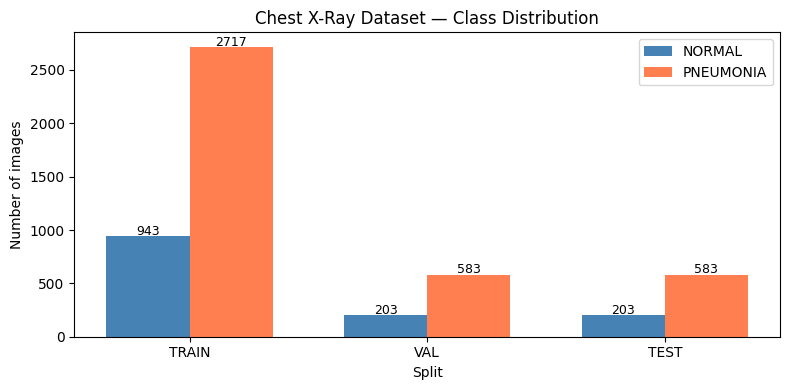


📊 Chart saved to /content/data/chest_xray_class_distribution.png


In [31]:
import matplotlib.pyplot as plt
from PIL import Image

print("=== FINAL DATASET STATS ===")
total_all = 0
for split in ["train", "val", "test"]:
    n_normal = len(glob.glob(os.path.join(OUTPUT_BASE, split, "NORMAL", "*.*")))
    n_pneumonia = len(glob.glob(os.path.join(OUTPUT_BASE, split, "PNEUMONIA", "*.*")))
    total = n_normal + n_pneumonia
    total_all += total
    pct_train = total / total_all * 100 if total_all > 0 else 0
    print(f"{split.upper():6s}  NORMAL={n_normal:4d}  PNEUMONIA={n_pneumonia:4d}  TOTAL={total:4d}  ({total/5863*100:.1f}% of original)")

print(f"\n{'TOTAL':6s}  {total_all} images")

# Visualize class distribution
fig, ax = plt.subplots(figsize=(8, 4))

splits_list = ["train", "val", "test"]
normal_counts = [len(glob.glob(os.path.join(OUTPUT_BASE, s, "NORMAL", "*.*"))) for s in splits_list]
pneumonia_counts = [len(glob.glob(os.path.join(OUTPUT_BASE, s, "PNEUMONIA", "*.*"))) for s in splits_list]

x = range(len(splits_list))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], normal_counts, width, label="NORMAL", color="steelblue")
bars2 = ax.bar([i + width/2 for i in x], pneumonia_counts, width, label="PNEUMONIA", color="coral")

ax.set_xlabel("Split")
ax.set_ylabel("Number of images")
ax.set_title("Chest X-Ray Dataset — Class Distribution")
ax.set_xticks(x)
ax.set_xticklabels([s.upper() for s in splits_list])
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(int(bar.get_height())), ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(int(bar.get_height())), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("/content/data/chest_xray_class_distribution.png", dpi=150)
plt.show()
print("\n📊 Chart saved to /content/data/chest_xray_class_distribution.png")

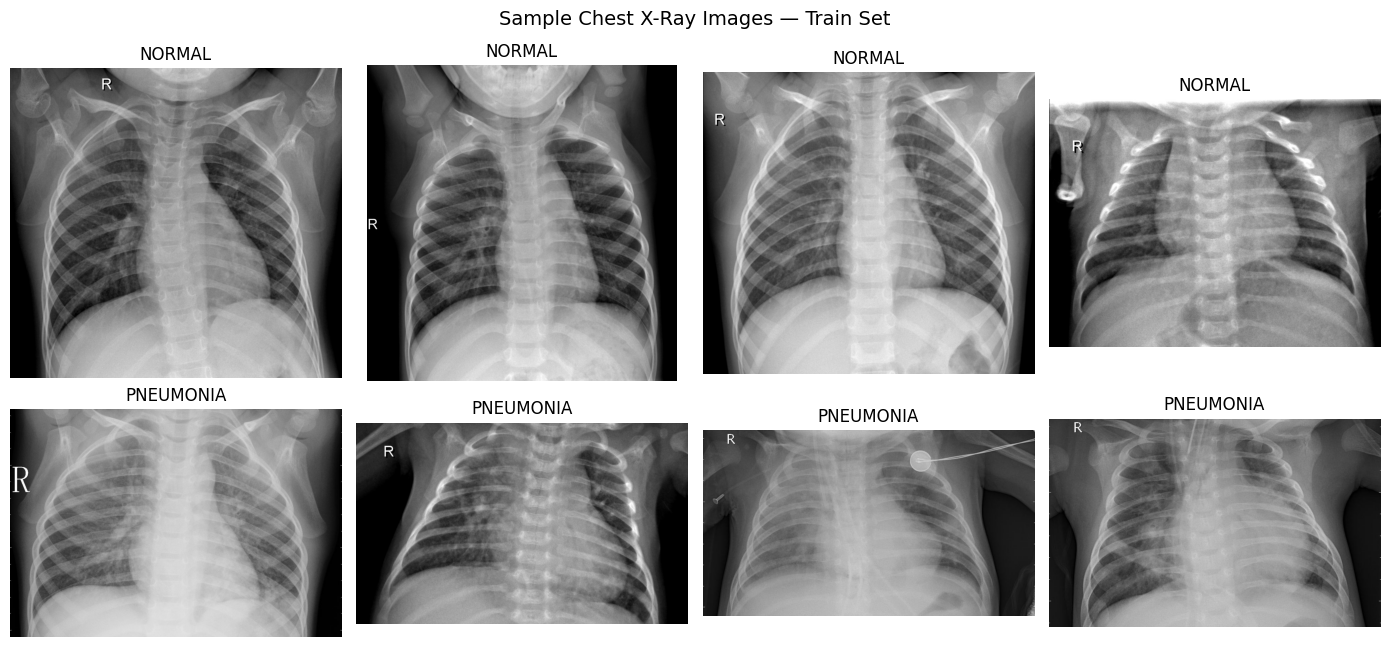

In [32]:
# Show sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for row, (split, label) in enumerate([("train", "NORMAL"), ("train", "PNEUMONIA")]):
    folder = os.path.join(OUTPUT_BASE, split, label)
    images = glob.glob(os.path.join(folder, "*.*"))[:4]
    for col, img_path in enumerate(images):
        img = Image.open(img_path).convert("RGB")
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{label}")
        axes[row, col].axis("off")

plt.suptitle("Sample Chest X-Ray Images — Train Set", fontsize=14)
plt.tight_layout()
plt.savefig("/content/data/chest_xray_samples.png", dpi=150)
plt.show()

---

## Step 7: Save Split Index (for reproducibility)

Simpan list file paths + labels ke CSV — berguna untuk debugging dan audit.

In [33]:
import pandas as pd

records = []
for split in ["train", "val", "test"]:
    for label in ["NORMAL", "PNEUMONIA"]:
        folder = os.path.join(OUTPUT_BASE, split, label)
        for img_path in glob.glob(os.path.join(folder, "*.*")):
            records.append({
                "path": img_path,
                "split": split,
                "label": label,
                "label_id": 0 if label == "NORMAL" else 1
            })

df = pd.DataFrame(records)
df.to_csv("/content/data/chest_xray_split.csv", index=False)

print(df.groupby(["split", "label"]).size().unstack(fill_value=0))
print(f"\n✅ Split index saved to /content/data/chest_xray_split.csv")
print(f"Total rows: {len(df)}")

label  NORMAL  PNEUMONIA
split                   
test      203        583
train     943       2717
val       203        583

✅ Split index saved to /content/data/chest_xray_split.csv
Total rows: 5232


---

## Checklist — Data Preparation

- [ ] Kaggle API token uploaded
- [ ] Dataset downloaded (~5,863 images)
- [ ] Re-split: 70% train / 15% val / 15% test (stratified)
- [ ] Folder structure organized
- [ ] Class distribution verified
- [ ] Split index CSV saved

---

## Next Step

**03_linear_probe.ipynb** — Linear probe evaluation:
1. Load V-JEPA 2 pretrained features (1024-dim)
2. Train linear classifier head on top
3. Evaluate on test set

⚠️ **Note:** Dataset kamu di `/content/data/chest_xray_v2/`. Paste path ini di notebook 03.